In [2]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt 
from PIL import Image
from src.features import augment_embeddings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, mean_squared_error
import joblib
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import random
import shap



In [4]:
df = pd.read_csv("../../outputs/analysis/data_quality/label_issues.csv")
df.sort_values(by = "confidence_in_given", ascending = False)

# New Variables
df["confidence_given_minus_sugg"] = df["confidence_in_suggested"] - df["confidence_in_given"]
df["given_minus_sugg_label"] = df["suggested_label"] - df["given_label"]

df = df[df["given_minus_sugg_label"] != 0]

In [5]:
data = np.load("../../outputs/segmented_embeddings/siglip2-so400m-14-384_clahe_embeddings.npz")
features, measurements_ids, labels = data["features"], data["measurement_ids"], data["labels"]

columns = ["length","quarter_2","quarter_3","quarter_4"]
metadata_csv = "../../cod_otolith_age_final_with_quarters.csv"


features = augment_embeddings(
                features, measurements_ids, metadata_csv, columns
            )

df_filter = df[df["confidence_in_given"] < 0.5]

mask = np.isin(measurements_ids, df_filter["measurement_id"])

feat_clean, labels_clean = features[~mask], labels[~mask]

rs = 77

X_train, X_test, y_train, y_test = train_test_split(feat_clean,
                                                    labels_clean,
                                                    test_size=0.15, 
                                                    stratify=labels_clean, 
                                                    random_state = rs)


print(f"Train set dimension: {len(X_train)}")
print(f"Test set dimension: {len(X_test)}")

print("="*60)
print("SCALING FEATURES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original feature shape: {X_train.shape}")
print(f"Scaled feature shape: {X_train_scaled.shape}")
print(f"Scaler fit on {X_train.shape[0]} samples")


Train set dimension: 5908
Test set dimension: 1043
SCALING FEATURES
Original feature shape: (5908, 1156)
Scaled feature shape: (5908, 1156)
Scaler fit on 5908 samples


# Train and Testing

In [26]:
# ========== TRAINING ==========

alphas = np.logspace(1.5, 2.7, 50)
print(f"Testing {len(alphas)} alpha values from {alphas.min():.4f} to {alphas.max():.4f}")

ridge = RidgeCV(alphas=alphas, cv=5) 
ridge.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge.alpha_:.6f}")

# Length and Quarters only

ridge_2 = RidgeCV(alphas=alphas, cv=5) 
ridge_2.fit(X_train_scaled[:, 1152:1156], y_train)

print(f"Best alpha 2: {ridge_2.alpha_:.6f}")

# Length and Quarters missing

ridge_3 = RidgeCV(alphas=alphas, cv=5) 
ridge_3.fit(X_train_scaled[:, :1152], y_train)

print(f"Best alpha 3: {ridge_3.alpha_:.6f}")


Testing 50 alpha values from 31.6228 to 501.1872
Best alpha: 181.628365
Best alpha 2: 31.622777
Best alpha 3: 285.168821



Full Model (1152 embeddings + 4 features)
R² Score:           0.8594
MAE:                0.4124 years
RMSE:               0.6799 years
Accuracy (±1 year): 97.51%
Accuracy (exact):   61.24%

Length + Quarters Only (4 features)
R² Score:           0.7660
MAE:                0.6029 years
RMSE:               0.8771 years
Accuracy (±1 year): 93.40%
Accuracy (exact):   47.18%

Embeddings Only (1152 features)
R² Score:           0.7907
MAE:                0.5617 years
RMSE:               0.8295 years
Accuracy (±1 year): 94.35%
Accuracy (exact):   49.76%

MODEL COMPARISON SUMMARY
Model                                          R²      MAE   Acc ±1yr  Acc exact
--------------------------------------------------------------------------------
Full Model (1152 embeddings + 4 features)   0.8594   0.4124     97.51%     61.24%
Length + Quarters Only (4 features)        0.7660   0.6029     93.40%     47.18%
Embeddings Only (1152 features)            0.7907   0.5617     94.35%     49.76%

KEY INSIGHTS


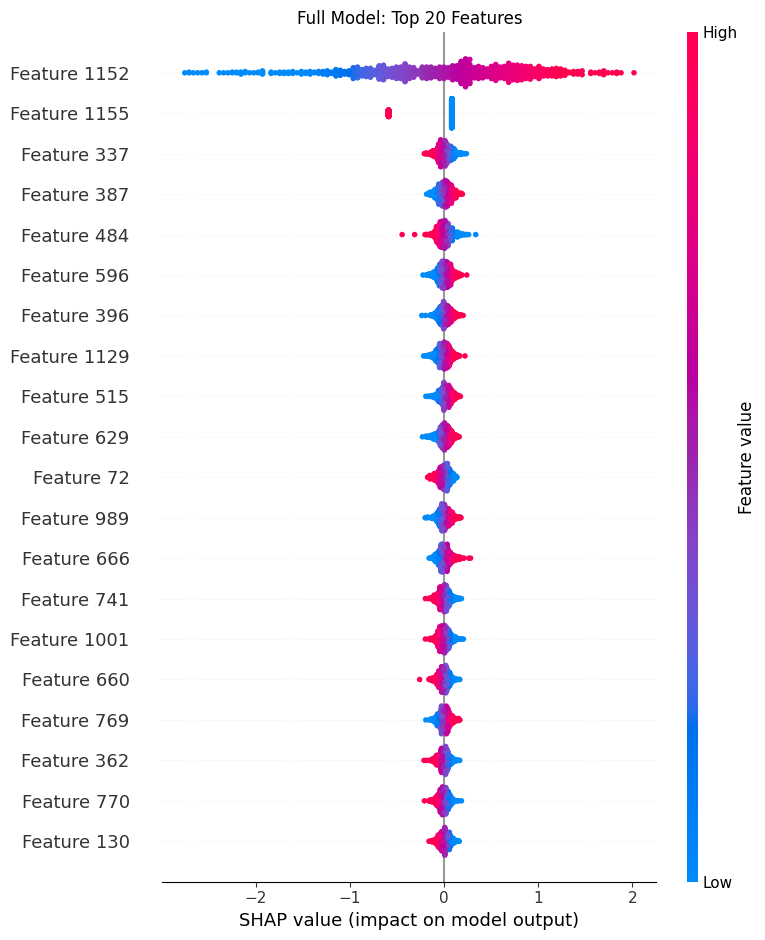

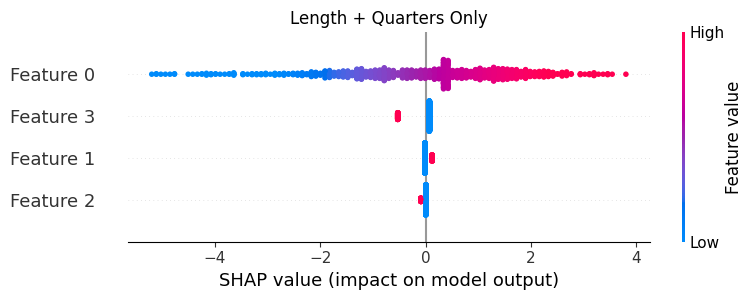

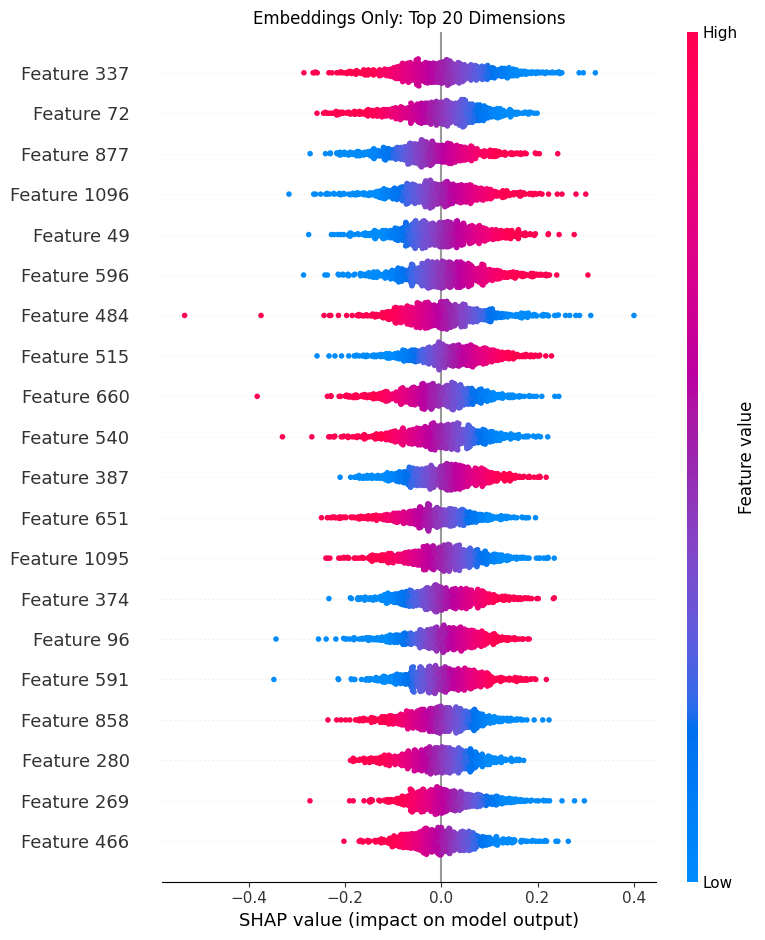

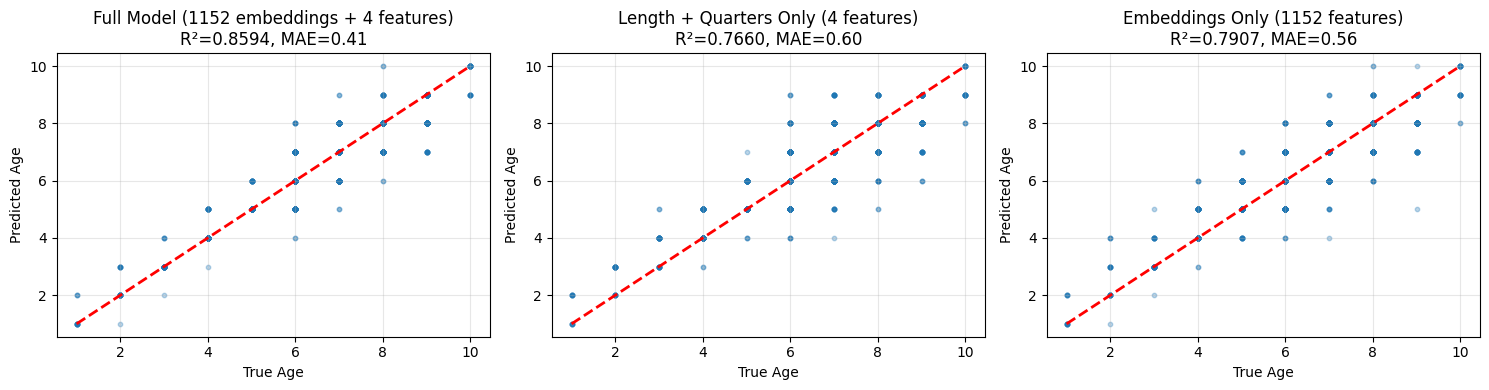

In [33]:
# ========== EVALUATION FUNCTION ==========

def evaluate_model(model, X_test, y_test, model_name):
    """Comprehensive model evaluation"""
    y_pred = np.round(model.predict(X_test)).astype(int)
    
    # Clip predictions to valid age range [1, 10]
    y_pred_clipped = np.clip(y_pred, 1, 10)
    
    # Metrics (using clipped predictions)
    r2 = r2_score(y_test, y_pred_clipped)
    mae = mean_absolute_error(y_test, y_pred_clipped)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_clipped))
    
    # Accuracy within ±1 year
    acc_1yr = np.mean(np.abs(y_pred_clipped - y_test) <= 1)
    
    # Exact accuracy (round to nearest integer)
    acc_exact = np.mean(y_pred_clipped == y_test)
    
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"R² Score:           {r2:.4f}")
    print(f"MAE:                {mae:.4f} years")
    print(f"RMSE:               {rmse:.4f} years")
    print(f"Accuracy (±1 year): {acc_1yr*100:.2f}%")
    print(f"Accuracy (exact):   {acc_exact*100:.2f}%")
    
    return {
        'model_name': model_name,
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'acc_1yr': acc_1yr,
        'acc_exact': acc_exact,
        'y_pred': y_pred_clipped
    }

# ========== EVALUATE ALL MODELS ==========

results = {}

# Model 1: Full model (embeddings + length + quarters)
results['full'] = evaluate_model(
    ridge, X_test_scaled, y_test, 
    "Full Model (1152 embeddings + 4 features)"
)

# Model 2: Length and quarters only
results['length_quarters'] = evaluate_model(
    ridge_2, X_test_scaled[:, 1152:1156], y_test,
    "Length + Quarters Only (4 features)"
)

# Model 3: Embeddings only (no length/quarters)
results['embeddings_only'] = evaluate_model(
    ridge_3, X_test_scaled[:, :1152], y_test,
    "Embeddings Only (1152 features)"
)

# ========== COMPARISON SUMMARY ==========

print(f"\n{'='*80}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*80}")
print(f"{'Model':<40} {'R²':>8} {'MAE':>8} {'Acc ±1yr':>10} {'Acc exact':>10}")
print(f"{'-'*80}")
for key, res in results.items():
    print(f"{res['model_name']:<40} {res['r2']:>8.4f} {res['mae']:>8.4f} {res['acc_1yr']*100:>9.2f}% {res['acc_exact']*100:>9.2f}%")

# Calculate improvements
r2_improvement_over_length = results['full']['r2'] - results['length_quarters']['r2']
mae_improvement_over_length = results['length_quarters']['mae'] - results['full']['mae']

print(f"\n{'='*70}")
print("KEY INSIGHTS")
print(f"{'='*70}")
print(f"Embeddings add {r2_improvement_over_length:.4f} R² over length alone")
print(f"Embeddings reduce MAE by {mae_improvement_over_length:.4f} years")
print(f"Relative R² improvement: {100*r2_improvement_over_length/results['length_quarters']['r2']:.1f}%")

# Check if embeddings alone beat length
if results['embeddings_only']['r2'] > results['length_quarters']['r2']:
    print(f"\n⚠️  Embeddings alone (R²={results['embeddings_only']['r2']:.4f}) outperform length+quarters (R²={results['length_quarters']['r2']:.4f})")
else:
    print(f"\n✓ Length+quarters (R²={results['length_quarters']['r2']:.4f}) outperform embeddings alone (R²={results['embeddings_only']['r2']:.4f})")

# ========== FEATURE IMPORTANCE ANALYSIS ==========

print(f"\n{'='*70}")
print("FEATURE IMPORTANCE ANALYSIS (Full Model)")
print(f"{'='*70}")

# Calculate SHAP values for full model
explainer = shap.LinearExplainer(ridge, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# 1. Total contribution by feature group
embedding_importance = np.abs(shap_values[:, :1152]).sum()
engineered_importance = np.abs(shap_values[:, 1152:]).sum()
total_importance = embedding_importance + engineered_importance

print(f"\nTotal Absolute SHAP Contribution:")
print(f"  Embeddings (1152 dims):    {embedding_importance:>10.2f} ({100*embedding_importance/total_importance:>5.1f}%)")
print(f"  Engineered features (4):   {engineered_importance:>10.2f} ({100*engineered_importance/total_importance:>5.1f}%)")

# 2. Mean importance per feature
mean_importance = np.abs(shap_values).mean(axis=0)

print(f"\nMean Absolute SHAP per Feature:")
print(f"  Avg embedding dimension:   {mean_importance[:1152].mean():.6f}")
print(f"  Avg engineered feature:    {mean_importance[1152:].mean():.6f}")
print(f"  Ratio (engineered/embed):  {mean_importance[1152:].mean() / mean_importance[:1152].mean():.1f}x")

# 3. Top features overall
top_k = 20
top_indices = np.argsort(mean_importance)[::-1][:top_k]
print(f"\nTop {top_k} Most Important Features:")
for rank, idx in enumerate(top_indices, 1):
    feat_type = "engineered" if idx >= 1152 else "embedding"
    print(f"  {rank:2d}. Feature {idx:4d} ({feat_type:>10s}): {mean_importance[idx]:.6f}")

# 4. Cumulative importance
sorted_importance = np.sort(mean_importance)[::-1]
cumulative_importance = np.cumsum(sorted_importance)
cumulative_pct = 100 * cumulative_importance / cumulative_importance[-1]

n_for_50 = np.argmax(cumulative_pct >= 50) + 1
n_for_90 = np.argmax(cumulative_pct >= 90) + 1

print(f"\nCumulative Importance:")
print(f"  Top {n_for_50:4d} features explain 50% of importance")
print(f"  Top {n_for_90:4d} features explain 90% of importance")
print(f"  Feature 1152 alone:  {100*mean_importance[1152]/cumulative_importance[-1]:.1f}% of total")

# 5. Embedding dimension distribution
print(f"\nEmbedding Dimension Importance Distribution:")
print(f"  Min:  {mean_importance[:1152].min():.6f}")
print(f"  25%:  {np.percentile(mean_importance[:1152], 25):.6f}")
print(f"  50%:  {np.percentile(mean_importance[:1152], 50):.6f}")
print(f"  75%:  {np.percentile(mean_importance[:1152], 75):.6f}")
print(f"  Max:  {mean_importance[:1152].max():.6f}")

# ========== VISUALIZATION ==========

# Summary plots for each model
print("\nGenerating SHAP summary plots...")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False, max_display=20)
plt.title("Full Model: Top 20 Features")
plt.tight_layout()
plt.show()

explainer_2 = shap.LinearExplainer(ridge_2, X_train_scaled[:, 1152:1156])
shap_values_2 = explainer_2.shap_values(X_test_scaled[:, 1152:1156])
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values_2, X_test_scaled[:, 1152:1156], show=False)
plt.title("Length + Quarters Only")
plt.tight_layout()
plt.show()

explainer_3 = shap.LinearExplainer(ridge_3, X_train_scaled[:, :1152])
shap_values_3 = explainer_3.shap_values(X_test_scaled[:, :1152])
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_3, X_test_scaled[:, :1152], show=False, max_display=20)
plt.title("Embeddings Only: Top 20 Dimensions")
plt.tight_layout()
plt.show()

# Prediction scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, res) in zip(axes, results.items()):
    ax.scatter(y_test, res['y_pred'], alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('True Age')
    ax.set_ylabel('Predicted Age')
    ax.set_title(f"{res['model_name']}\nR²={res['r2']:.4f}, MAE={res['mae']:.2f}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
y_pred_ensemble = 1.*ridge.predict(X_test_scaled) 

y_pred_ensemble = np.round(y_pred_ensemble)
y_pred_ensemble = np.clip(y_pred_ensemble, 1, 10)

accuracy_score(y_test, y_pred_ensemble)





0.6124401913875598